## Random Forest
Instead of one decision tree, it uses many decision trees. Every tree gives it's own prediction and random forest combines them. For regression, it takes average. A collection of trees is called Forest.

### Bagging
It stands for Bootstrap Aggregating.  
Each tree is trained on a different random subset of the training data.  
So every tree learns something slightly different.  
This reduces overfitting.  
If all trees are trained on the same data, will they all be identical? Yes.  
Then what's the point?  
So Random Forest introduces randomness by:  
Using different random subsets of the data (Bagging).  
Considering random subsets of features while splitting.  
This makes each tree unique.  
But this is slower than single decison tree.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib  

df = pd.read_csv("../data/housing.csv")
X = df.drop(["Price", "Address"], axis=1)
y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

MAE : 94516.8807407428
RMSE: 119975.32778538977
R² : 0.8830058342815131


R² increased by about 0.14, which is a significant improvement.

This proves that using multiple trees helps reduce the overfitting problem of a single Decision Tree.

In [2]:
joblib.dump(
    rf_model,
    "../models/random_forest_model.joblib"
)

['../models/random_forest_model.joblib']

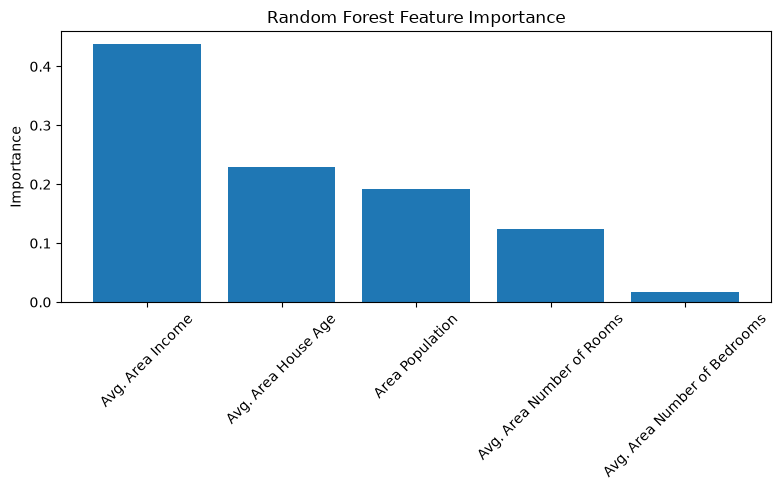

In [3]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("Random Forest Feature Importance")

plt.ylabel("Importance")

plt.tight_layout()

plt.show()